In [1]:
# initialize packages
#let's build a mini-banking analytics dashboard
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
BASE_DIR = Path.cwd()
print(BASE_DIR)

d:\data-science-journey\notebooks


In [3]:
#create our first dataset
data = {
    "customer_name": ["John", "Mary", "David", "Sarah", "Mike"],
    "age": [25, 34, 29, 42, 31],
    "branch": ["Nairobi", "Mombasa", "Nairobi", "Kisumu", "Nakuru"],
    "account_balance": [45000, 120000, 67000, 98000, 52000],
    "loan_status": ["No Loan", "Active", "Closed", "Active", "No Loan"]
}

df = pd.DataFrame(data)

#inspect our data
df.head()





,customer_name,age,branch,account_balance,loan_status
0,John,25,Nairobi,45000,No Loan
1,Mary,34,Mombasa,120000,Active
2,David,29,Nairobi,67000,Closed
3,Sarah,42,Kisumu,98000,Active
4,Mike,31,Nakuru,52000,No Loan


In [4]:
#get more info about our data
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   customer_name    5 non-null      str  
 1   age              5 non-null      int64
 2   branch           5 non-null      str  
 3   account_balance  5 non-null      int64
 4   loan_status      5 non-null      str  
dtypes: int64(2), str(3)
memory usage: 332.0 bytes


In [5]:
#get statistics about our data
df.describe()

,age,account_balance
count,5.000000,5.000000
mean,32.200000,76400.000000
std,6.379655,31769.482212
min,25.000000,45000.000000
25%,29.000000,52000.000000
50%,31.000000,67000.000000
75%,34.000000,98000.000000
max,42.000000,120000.000000


In [6]:
#add new columns
df["balance_category"] = np.where(
    df["account_balance"] > 70000,
    "High Balance",
    "Normal Balance"
)

#inspect our data again
df.head()

,customer_name,age,branch,account_balance,loan_status,balance_category
0,John,25,Nairobi,45000,No Loan,Normal Balance
1,Mary,34,Mombasa,120000,Active,High Balance
2,David,29,Nairobi,67000,Closed,Normal Balance
3,Sarah,42,Kisumu,98000,Active,High Balance
4,Mike,31,Nakuru,52000,No Loan,Normal Balance


In [7]:
#multiple conditions filtering
#filter customers with high balance and active loan status
filtered_df = df[
    (df["account_balance"] > 50000) &
    (df["loan_status"] == "Active")
]

filtered_df.head()

,customer_name,age,branch,account_balance,loan_status,balance_category
1,Mary,34,Mombasa,120000,Active,High Balance
3,Sarah,42,Kisumu,98000,Active,High Balance


In [8]:
#value counts
df["branch"].value_counts()



branch
Nairobi    2
Mombasa    1
Kisumu     1
Nakuru     1
Name: count, dtype: int64

In [9]:

#value counts - loan status
df["loan_status"].value_counts()

loan_status
No Loan    2
Active     2
Closed     1
Name: count, dtype: int64

In [10]:
#unique values in branch column
df["branch"].unique()

<StringArray>
['Nairobi', 'Mombasa', 'Kisumu', 'Nakuru']
Length: 4, dtype: str

In [11]:
#count unique values in branch column
df["branch"].nunique()

4

In [12]:
#rename columns
df.rename(columns={
    "account_balance": "balance"
}, inplace=True)

df

,customer_name,age,branch,balance,loan_status,balance_category
0,John,25,Nairobi,45000,No Loan,Normal Balance
1,Mary,34,Mombasa,120000,Active,High Balance
2,David,29,Nairobi,67000,Closed,Normal Balance
3,Sarah,42,Kisumu,98000,Active,High Balance
4,Mike,31,Nakuru,52000,No Loan,Normal Balance


In [13]:
#functions
#define risk levels
def risk_level(balance):
    if balance > 80000:
        return "Low Risk"
    elif balance > 50000:
        return "Medium Risk"
    else:
        return "High Risk"


In [14]:
#aply function to create new risk level column
df["risk_level"] = df["balance"].apply(risk_level)
df

,customer_name,age,branch,balance,loan_status,balance_category,risk_level
0,John,25,Nairobi,45000,No Loan,Normal Balance,High Risk
1,Mary,34,Mombasa,120000,Active,High Balance,Low Risk
2,David,29,Nairobi,67000,Closed,Normal Balance,Medium Risk
3,Sarah,42,Kisumu,98000,Active,High Balance,Low Risk
4,Mike,31,Nakuru,52000,No Loan,Normal Balance,Medium Risk


In [15]:
#sort multiple columns
df.sort_values(
    by=["branch", "balance"],
    ascending=[True, False]
)

,customer_name,age,branch,balance,loan_status,balance_category,risk_level
3,Sarah,42,Kisumu,98000,Active,High Balance,Low Risk
1,Mary,34,Mombasa,120000,Active,High Balance,Low Risk
2,David,29,Nairobi,67000,Closed,Normal Balance,Medium Risk
0,John,25,Nairobi,45000,No Loan,Normal Balance,High Risk
4,Mike,31,Nakuru,52000,No Loan,Normal Balance,Medium Risk


In [16]:
#analytics
#aggregations
df.groupby("branch")["balance"].agg([
    "mean",
    "max",
    "min",
    "sum"
])

,mean,max,min,sum
branch,,,,
Kisumu,98000.0,98000,98000,98000
Mombasa,120000.0,120000,120000,120000
Nairobi,56000.0,67000,45000,112000
Nakuru,52000.0,52000,52000,52000


In [17]:
#LOC Label based - specific row
df.loc[0]

customer_name                 John
age                             25
branch                     Nairobi
balance                      45000
loan_status                No Loan
balance_category    Normal Balance
risk_level               High Risk
Name: 0, dtype: object

In [18]:
#LOC -Specific value
df.loc[0,"customer_name"]

'John'

In [19]:
#LOC Label based - multiple rows
df.loc[0:2]

,customer_name,age,branch,balance,loan_status,balance_category,risk_level
0,John,25,Nairobi,45000,No Loan,Normal Balance,High Risk
1,Mary,34,Mombasa,120000,Active,High Balance,Low Risk
2,David,29,Nairobi,67000,Closed,Normal Balance,Medium Risk


In [20]:
#ILOC - Index based - specific row
df.iloc[0]

customer_name                 John
age                             25
branch                     Nairobi
balance                      45000
loan_status                No Loan
balance_category    Normal Balance
risk_level               High Risk
Name: 0, dtype: object

In [21]:
#ILOC -Multiple rows
df.iloc[0:3]

,customer_name,age,branch,balance,loan_status,balance_category,risk_level
0,John,25,Nairobi,45000,No Loan,Normal Balance,High Risk
1,Mary,34,Mombasa,120000,Active,High Balance,Low Risk
2,David,29,Nairobi,67000,Closed,Normal Balance,Medium Risk


In [22]:
#ILOC -Multiple rows and columns
df.iloc[0:3, 0:2]

,customer_name,age
0,John,25
1,Mary,34
2,David,29


In [23]:
#Query method
df.query("balance > 60000")

,customer_name,age,branch,balance,loan_status,balance_category,risk_level
1,Mary,34,Mombasa,120000,Active,High Balance,Low Risk
2,David,29,Nairobi,67000,Closed,Normal Balance,Medium Risk
3,Sarah,42,Kisumu,98000,Active,High Balance,Low Risk


In [24]:
#Query method - multiple conditions
df.query("balance > 60000 and loan_status == 'Active'")

,customer_name,age,branch,balance,loan_status,balance_category,risk_level
1,Mary,34,Mombasa,120000,Active,High Balance,Low Risk
3,Sarah,42,Kisumu,98000,Active,High Balance,Low Risk


In [25]:
#exporting data to csv
DATASET_DIR = BASE_DIR / "datasets"
df.to_csv("../datasets/customer_data.csv", index=False)

In [26]:
#exporting data to excel
DATASET_DIR = BASE_DIR / "datasets"
df.to_csv("../datasets/customer_data.xlsx", index=False)

In [27]:
#create a summary report
def branch_summary(branch_name):
    branch_data = df[df["branch"] == branch_name]

    print("Branch:", branch_name)
    print("Total Customers:", len(branch_data))
    print("Average Balance:", branch_data["balance"].mean())
    print("Maximum Balance:", branch_data["balance"].max())

In [28]:
#Call the report
branch_summary("Nairobi")

Branch: Nairobi
Total Customers: 2
Average Balance: 56000.0
Maximum Balance: 67000


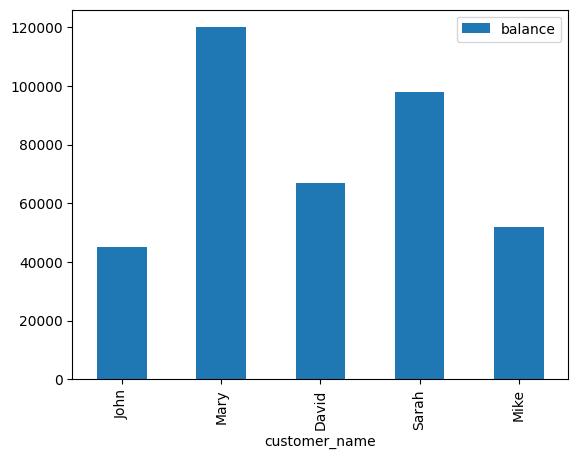

In [29]:
#visualization
df.plot(
    x="customer_name",
    y="balance",
    kind="bar"
)

plt.show()

In [30]:
#Let's create a customer scoring function
def customer_tier(balance):

    if balance >= 100000:
        return "Platinum"

    elif balance >= 60000:
        return "Gold"

    else:
        return "Silver"

In [31]:
#apply the function to create a new customer tier column
df["customer_tier"] = df["balance"].apply(customer_tier)

df

,customer_name,age,branch,balance,loan_status,balance_category,risk_level,customer_tier
0,John,25,Nairobi,45000,No Loan,Normal Balance,High Risk,Silver
1,Mary,34,Mombasa,120000,Active,High Balance,Low Risk,Platinum
2,David,29,Nairobi,67000,Closed,Normal Balance,Medium Risk,Gold
3,Sarah,42,Kisumu,98000,Active,High Balance,Low Risk,Gold
4,Mike,31,Nakuru,52000,No Loan,Normal Balance,Medium Risk,Silver


In [32]:
#fraud detection - flag customers with high balance but no active loan
# we're using np.where()
df["fraud_review"] = np.where(
    df["balance"] > 100000,
    "Review Required",
    "Normal"
)

df


,customer_name,age,branch,balance,loan_status,balance_category,risk_level,customer_tier,fraud_review
0,John,25,Nairobi,45000,No Loan,Normal Balance,High Risk,Silver,Normal
1,Mary,34,Mombasa,120000,Active,High Balance,Low Risk,Platinum,Review Required
2,David,29,Nairobi,67000,Closed,Normal Balance,Medium Risk,Gold,Normal
3,Sarah,42,Kisumu,98000,Active,High Balance,Low Risk,Gold,Normal
4,Mike,31,Nakuru,52000,No Loan,Normal Balance,Medium Risk,Silver,Normal


In [33]:
#Let's create branch dashboard summary
branch_summary = df.groupby("branch").agg({

    "balance": ["sum", "mean", "max", "min"],
    "customer_name": "count"

})

branch_summary

balance                           customer_name
            sum      mean     max     min         count
branch                                                 
Kisumu    98000   98000.0   98000   98000             1
Mombasa  120000  120000.0  120000  120000             1
Nairobi  112000   56000.0   67000   45000             2
Nakuru    52000   52000.0   52000   52000             1

In [34]:
#let's clean the column names in our branch summary
branch_summary.columns = [

    "total_balance",
    "average_balance",
    "highest_balance",
    "lowest_balance",
    "total_customers"

]

branch_summary

,total_balance,average_balance,highest_balance,lowest_balance,total_customers
branch,,,,,
Kisumu,98000,98000.0,98000,98000,1
Mombasa,120000,120000.0,120000,120000,1
Nairobi,112000,56000.0,67000,45000,2
Nakuru,52000,52000.0,52000,52000,1


In [35]:
#let's sort the dashboard
#by total balance
branch_summary.sort_values(
    by="total_balance",
    ascending=False
)

,total_balance,average_balance,highest_balance,lowest_balance,total_customers
branch,,,,,
Mombasa,120000,120000.0,120000,120000,1
Nairobi,112000,56000.0,67000,45000,2
Kisumu,98000,98000.0,98000,98000,1
Nakuru,52000,52000.0,52000,52000,1


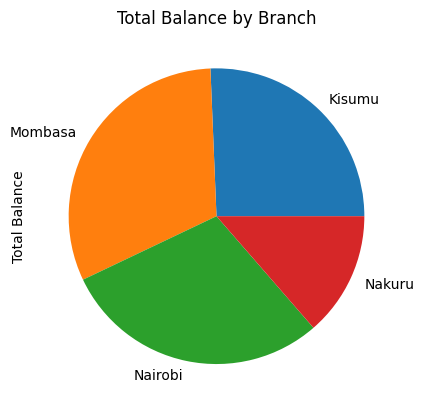

In [36]:
#let's visualize our dashboard
branch_summary["total_balance"].plot(
    kind="pie"
)

plt.title("Total Balance by Branch")

plt.ylabel("Total Balance")

plt.show()

In [37]:
#We have just created a mini-banking analytics dashboard